# ML — Employee Attrition: Preprocessing

**Goal:** Prepare the IBM HR dataset for machine learning — encode categoricals, scale numerics, handle class imbalance, and split into train/test sets.

---
**Sections:**
1. Load & Clean
2. Encode Categorical Variables
3. Feature Scaling
4. Train / Test Split
5. Handle Class Imbalance
6. Save Processed Data

## 1. Load & Clean

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DATA_PATH = '../01_eda/data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Drop columns with zero variance — they carry no information
constant_cols = ['EmployeeCount', 'StandardHours', 'Over18']
df.drop(columns=constant_cols, inplace=True)

# Drop employee ID — not a predictive feature
df.drop(columns=['EmployeeNumber'], inplace=True)

print(f'Shape after cleanup: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape after cleanup: (1470, 31)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 2. Encode Categorical Variables

In [3]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')

Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [4]:
# Encode target: Attrition Yes=1, No=0
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

# Binary columns — map directly
df['OverTime'] = (df['OverTime'] == 'Yes').astype(int)

# Ordinal column — BusinessTravel has a natural order
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(travel_map)

# Remaining categoricals — one-hot encoding
remaining_cats = ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=remaining_cats, drop_first=True)

print(f'Shape after encoding: {df.shape}')
df.head()

Shape after encoding: (1470, 44)


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,1,2,2,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,2,279,8,1,3,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1,1373,2,2,4,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,2,1392,3,4,4,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,1,591,2,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


## 3. Train / Test Split

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Stratify to preserve class balance in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size:  {X_test.shape[0]} samples')
print(f'\nAttrition rate in train: {y_train.mean():.1%}')
print(f'Attrition rate in test:  {y_test.mean():.1%}')

Train size: 1176 samples
Test size:  294 samples

Attrition rate in train: 16.2%
Attrition rate in test:  16.0%


## 4. Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

# Scale only numeric columns (not the binary/encoded ones)
num_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
            'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
            'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
            'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

scaler = StandardScaler()

# Fit on train only — never on test (avoids data leakage)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Scaling applied.')
X_train.describe().round(2)

Scaling applied.


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,...,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00
mean,-0.00,1.09,0.00,-0.00,2.91,2.72,-0.00,2.74,2.08,2.72,...,3.16,2.74,0.79,-0.00,0.00,2.76,-0.00,0.00,-0.00,0.00
std,1.00,0.54,1.00,1.00,1.03,1.09,1.00,0.70,1.09,1.11,...,0.36,1.09,0.85,1.00,1.00,0.72,1.00,1.00,1.00,1.00
min,-2.07,0.00,-1.75,-1.02,1.00,1.00,-1.74,1.00,1.00,1.00,...,3.00,1.00,0.00,-1.46,-2.20,1.00,-1.16,-1.19,-0.68,-1.18
25%,-0.76,1.00,-0.84,-0.90,2.00,2.00,-0.86,2.00,1.00,2.00,...,3.00,2.00,0.00,-0.69,-0.61,2.00,-0.67,-0.63,-0.68,-0.62
50%,-0.11,1.00,-0.01,-0.29,3.00,3.00,0.02,3.00,2.00,3.00,...,3.00,3.00,1.00,-0.18,0.19,3.00,-0.34,-0.35,-0.37,-0.34
75%,0.65,1.00,0.88,0.57,4.00,4.00,0.86,3.00,3.00,4.00,...,3.00,4.00,1.00,0.47,0.19,3.00,0.48,0.78,0.25,0.79
max,2.51,2.00,1.73,2.40,5.00,4.00,1.69,4.00,5.00,4.00,...,4.00,4.00,3.00,3.67,2.58,4.00,4.92,3.58,3.99,3.59


## 5. Class Imbalance

The dataset is imbalanced (~84% stayed, ~16% left). We handle this using `class_weight='balanced'` in the models rather than oversampling, to avoid artificially inflating the minority class.

Class distribution in training set:
  Stayed (0): 986 (83.8%)
  Left   (1): 190 (16.2%)


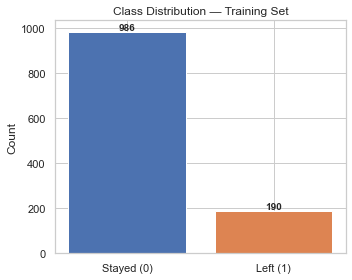

In [7]:
class_counts = y_train.value_counts()
print(f'Class distribution in training set:')
print(f'  Stayed (0): {class_counts[0]} ({class_counts[0]/len(y_train):.1%})')
print(f'  Left   (1): {class_counts[1]} ({class_counts[1]/len(y_train):.1%})')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Stayed (0)', 'Left (1)'], class_counts.values, color=['#4C72B0', '#DD8452'])
ax.set_title('Class Distribution — Training Set')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Save Processed Data

In [8]:
import os

os.makedirs('data', exist_ok=True)

X_train.to_csv('data/X_train.csv', index=False)
X_test.to_csv('data/X_test.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

# Save feature names for use in modeling notebook
pd.Series(X_train.columns.tolist()).to_csv('data/feature_names.csv', index=False)

print('Saved:')
print('  data/X_train.csv')
print('  data/X_test.csv')
print('  data/y_train.csv')
print('  data/y_test.csv')
print('  data/feature_names.csv')
print(f'\nFeatures: {X_train.shape[1]}')

Saved:
  data/X_train.csv
  data/X_test.csv
  data/y_train.csv
  data/y_test.csv
  data/feature_names.csv

Features: 43
